ADIM-0 Yapısal inceleme

In [25]:
#Librarys
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import defaultdict

# Grafik ayarları
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")

print("Kütüphaneler yüklendi.")

Kütüphaneler yüklendi.


In [26]:
#import the data set
DATASET_PATH = "../data/raw/radioml_2016/RML2016.10a_dict.pkl"

with open(DATASET_PATH, "rb") as f:
    dataset = pickle.load(f, encoding="latin1")

print("Yükleme başarılı!")
print(f"Nesne tipi  : {type(dataset)}")
print(f"Toplam anahtar sayısı: {len(dataset.keys())}")

Yükleme başarılı!
Nesne tipi  : <class 'dict'>
Toplam anahtar sayısı: 220


In [27]:
#Analyse Keys
all_keys = list(dataset.keys())

# Modülasyon ve SNR değerlerini çıkar
modulations = sorted(set(k[0] for k in all_keys))
snr_values  = sorted(set(k[1] for k in all_keys))

print("İlk 5 anahtar :", all_keys[:5])
print()
print("Modülasyon tipleri :", modulations)
print("Modülasyon sayısı  :", len(modulations))
print()
print("SNR değerleri (dB) :", snr_values)
print("SNR seviye sayısı  :", len(snr_values))
print()
print(f"Beklenen toplam anahtar: {len(modulations)} x {len(snr_values)} = "
      f"{len(modulations)*len(snr_values)}")

İlk 5 anahtar : [('QPSK', 2), ('PAM4', 8), ('AM-DSB', -4), ('GFSK', 6), ('QAM64', 8)]

Modülasyon tipleri : ['8PSK', 'AM-DSB', 'AM-SSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']
Modülasyon sayısı  : 11

SNR değerleri (dB) : [-20, -18, -16, -14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12, 14, 16, 18]
SNR seviye sayısı  : 20

Beklenen toplam anahtar: 11 x 20 = 220


In [28]:
# Örnek bir anahtar seç
sample_key  = ('BPSK', 0)
sample_data = dataset[sample_key]

print(f"Seçilen anahtar    : {sample_key}")
print(f"Değer tipi         : {type(sample_data)}")
print(f"Şekil (shape)      : {sample_data.shape}")
print(f"Veri tipi (dtype)  : {sample_data.dtype}")
print()

single_signal = sample_data[0]   # ilk sinyal
print(f"Tek sinyal şekli   : {single_signal.shape}  →  (kanal, zaman_adımı)")
print(f"I kanalı (ilk 8)   : {single_signal[0, :8].round(4)}")
print(f"Q kanalı (ilk 8)   : {single_signal[1, :8].round(4)}")

Seçilen anahtar    : ('BPSK', 0)
Değer tipi         : <class 'numpy.ndarray'>
Şekil (shape)      : (1000, 2, 128)
Veri tipi (dtype)  : float32

Tek sinyal şekli   : (2, 128)  →  (kanal, zaman_adımı)
I kanalı (ilk 8)   : [ 0.0065 -0.0028  0.0026 -0.0037  0.0049  0.0091 -0.0039  0.    ]
Q kanalı (ilk 8)   : [-0.0069 -0.0034 -0.0104 -0.0098 -0.0117 -0.0043 -0.006   0.0019]


In [29]:
samples_per_pair = sample_data.shape[0]
total_samples    = len(all_keys) * samples_per_pair

print("=" * 52)
print("  RadioML 2016.10a — Veri Seti Özeti")
print("=" * 52)
print(f"  (mod, SNR) çift sayısı  : {len(all_keys)}")
print(f"  Modülasyon sınıfı       : {len(modulations)}")
print(f"  SNR aralığı             : {min(snr_values)} dB → {max(snr_values)} dB")
print(f"  Her çift için örnek     : {samples_per_pair}")
print(f"  Toplam örnek sayısı     : {total_samples:,}")
print(f"  Sinyal şekli            : {single_signal.shape}  [kanal × adım]")
print(f"  Kanallar                : 0=I (In-phase), 1=Q (Quadrature)")
print(f"  Zaman adımı sayısı      : {single_signal.shape[1]}")
print("=" * 52)

  RadioML 2016.10a — Veri Seti Özeti
  (mod, SNR) çift sayısı  : 220
  Modülasyon sınıfı       : 11
  SNR aralığı             : -20 dB → 18 dB
  Her çift için örnek     : 1000
  Toplam örnek sayısı     : 220,000
  Sinyal şekli            : (2, 128)  [kanal × adım]
  Kanallar                : 0=I (In-phase), 1=Q (Quadrature)
  Zaman adımı sayısı      : 128


In [30]:
print("Veri Kalitesi Kontrolleri")
print("-" * 40)

nan_count = 0
inf_count = 0
shape_errors = 0

for key, signals in dataset.items():
    if np.isnan(signals).any():
        nan_count += 1
    if np.isinf(signals).any():
        inf_count += 1
    if signals.shape != (1000, 2, 128):
        shape_errors += 1

print(f"NaN içeren anahtar sayısı   : {nan_count}")
print(f"Inf içeren anahtar sayısı   : {inf_count}")
print(f"Yanlış shape'li anahtar     : {shape_errors}")

val_min = min(dataset[k].min() for k in all_keys)
val_max = max(dataset[k].max() for k in all_keys)
print(f"Genel min değer             : {val_min:.4f}")
print(f"Genel max değer             : {val_max:.4f}")

if nan_count == 0 and inf_count == 0 and shape_errors == 0:
    print("\nTüm kontroller geçti — veri seti temiz.")

Veri Kalitesi Kontrolleri
----------------------------------------
NaN içeren anahtar sayısı   : 0
Inf içeren anahtar sayısı   : 0
Yanlış shape'li anahtar     : 0
Genel min değer             : -0.1549
Genel max değer             : 0.1642

Tüm kontroller geçti — veri seti temiz.


ADIM-1 Dağılım analizi

In [31]:
# Tüm veriyi düz listeye çevir — mod etiketi, SNR ve sinyal birlikte
X_list, y_list, snr_list = [], [], []

for (mod, snr), signals in dataset.items():
    for i in range(signals.shape[0]):          # 1000 sinyal
        X_list.append(signals[i])              # (2, 128)
        y_list.append(mod)                     # string etiket
        snr_list.append(snr)                   # int

X   = np.array(X_list, dtype=np.float32)      # (220000, 2, 128)
y   = np.array(y_list)                        # (220000,)
snr = np.array(snr_list)                      # (220000,)

print(f"X shape   : {X.shape}")
print(f"y shape   : {y.shape}  — örnek: {y[:3]}")
print(f"snr shape : {snr.shape} — örnek: {snr[:3]}")

X shape   : (220000, 2, 128)
y shape   : (220000,)  — örnek: ['QPSK' 'QPSK' 'QPSK']
snr shape : (220000,) — örnek: [2 2 2]


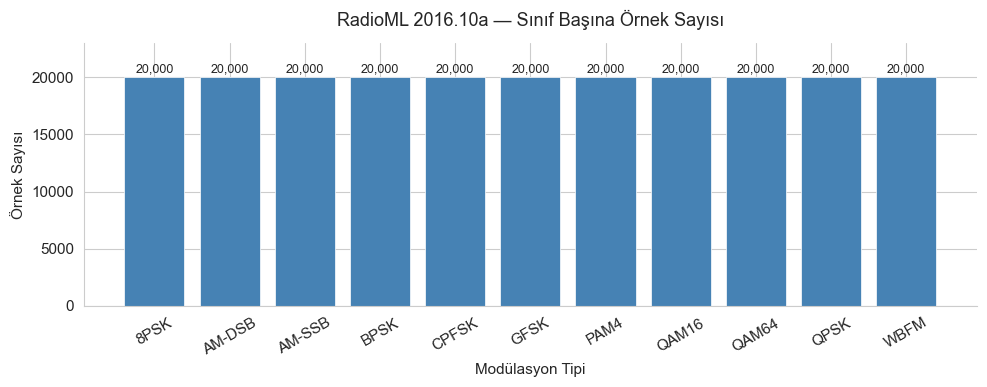


Sınıf başına örnek sayısı:
8PSK      20000
AM-DSB    20000
AM-SSB    20000
BPSK      20000
CPFSK     20000
GFSK      20000
PAM4      20000
QAM16     20000
QAM64     20000
QPSK      20000
WBFM      20000


In [32]:
fig, ax = plt.subplots(figsize=(10, 4))

class_counts = pd.Series(y).value_counts().sort_index()
bars = ax.bar(class_counts.index, class_counts.values,
              color='steelblue', edgecolor='white', linewidth=0.5)

# Her çubuğun üstüne değer yaz
for bar, val in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}', ha='center', va='bottom', fontsize=9)

ax.set_title('RadioML 2016.10a — Sınıf Başına Örnek Sayısı', fontsize=13, pad=12)
ax.set_xlabel('Modülasyon Tipi')
ax.set_ylabel('Örnek Sayısı')
ax.set_ylim(0, class_counts.max() * 1.15)
ax.tick_params(axis='x', rotation=30)
sns.despine()
plt.tight_layout()
plt.savefig('../results/results_2016/eda_2016_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSınıf başına örnek sayısı:")
print(class_counts.to_string())

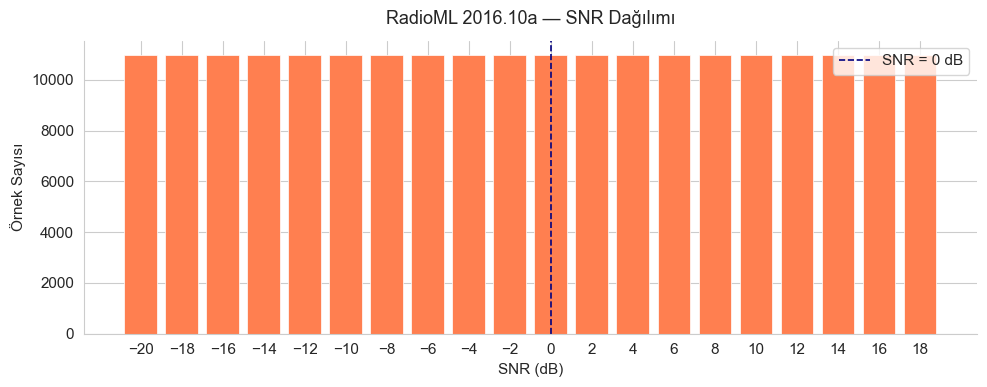

In [33]:
fig, ax = plt.subplots(figsize=(10, 4))

snr_counts = pd.Series(snr).value_counts().sort_index()
ax.bar(snr_counts.index, snr_counts.values,
       width=1.6, color='coral', edgecolor='white', linewidth=0.5)

ax.axvline(x=0, color='navy', linestyle='--', linewidth=1.2, label='SNR = 0 dB')
ax.set_title('RadioML 2016.10a — SNR Dağılımı', fontsize=13, pad=12)
ax.set_xlabel('SNR (dB)')
ax.set_ylabel('Örnek Sayısı')
ax.set_xticks(snr_values)
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig('../results/results_2016/eda_2016_snr_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

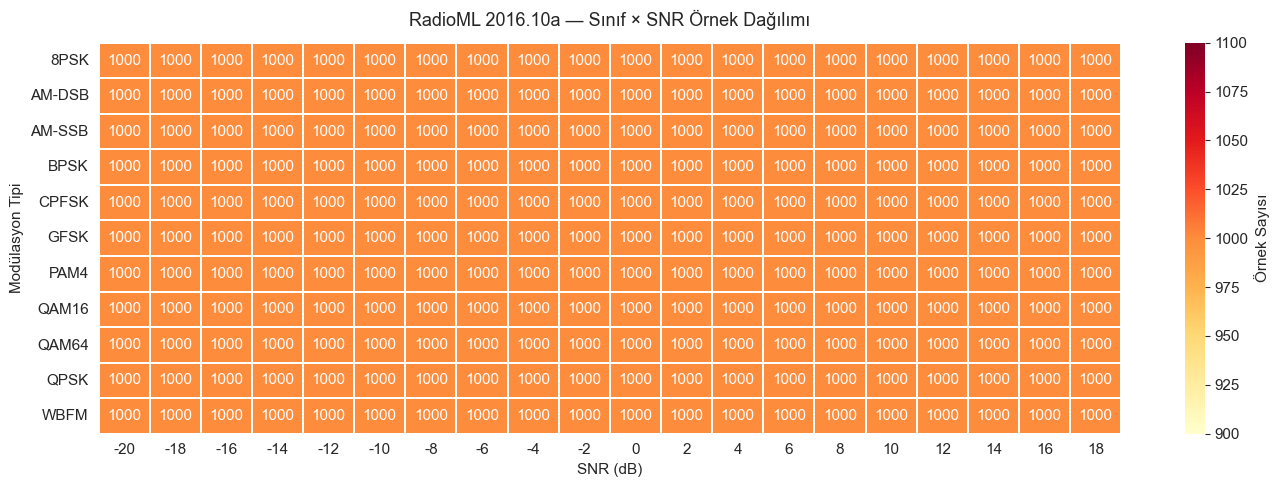


Veri seti dengeli mi?
Min örnek (herhangi bir hücre): 1000.0
Max örnek (herhangi bir hücre): 1000.0


In [34]:
# Her (sınıf, SNR) çifti için örnek sayısını say
heatmap_data = pd.DataFrame(index=modulations, columns=snr_values, dtype=int)

for mod in modulations:
    for snr_val in snr_values:
        key = (mod, snr_val)
        heatmap_data.loc[mod, snr_val] = dataset[key].shape[0]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(heatmap_data.astype(int), annot=True, fmt='d',
            cmap='YlOrRd', linewidths=0.3, linecolor='white',
            ax=ax, cbar_kws={'label': 'Örnek Sayısı'})

ax.set_title('RadioML 2016.10a — Sınıf × SNR Örnek Dağılımı', fontsize=13, pad=12)
ax.set_xlabel('SNR (dB)')
ax.set_ylabel('Modülasyon Tipi')
plt.tight_layout()
plt.savefig('../results/results_2016/eda_2016_class_snr_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nVeri seti dengeli mi?")
print(f"Min örnek (herhangi bir hücre): {heatmap_data.min().min()}")
print(f"Max örnek (herhangi bir hücre): {heatmap_data.max().max()}")

ADIM 2 — Dalga biçimleri

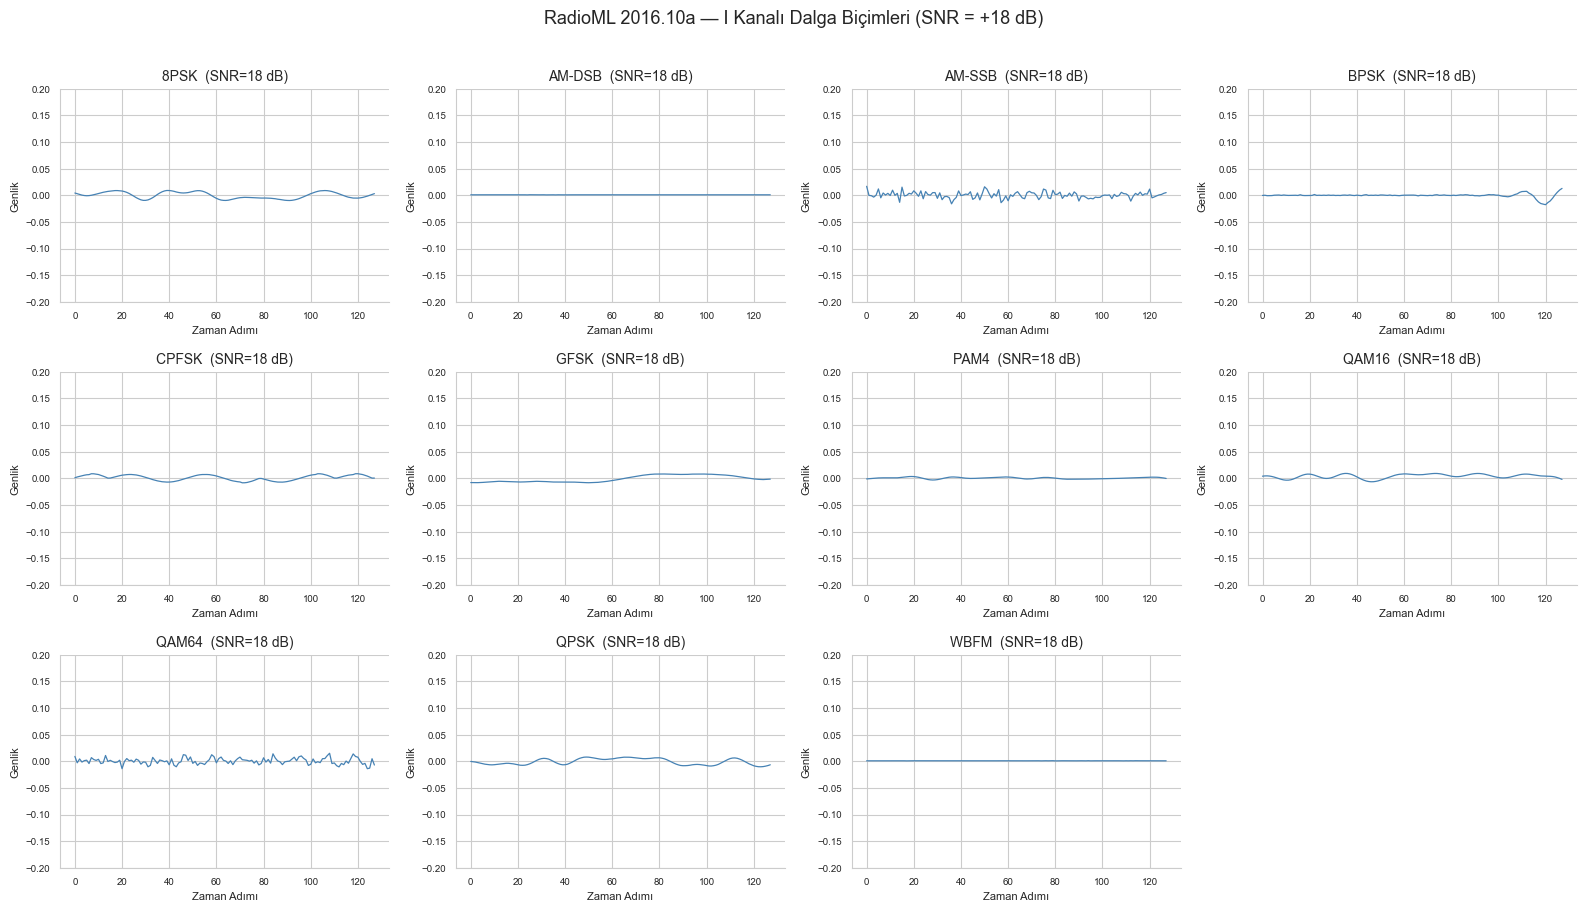

In [35]:
# Yüksek SNR'da (18 dB) her modülasyonun I kanalını göster
fig, axes = plt.subplots(3, 4, figsize=(16, 9))
axes = axes.flatten()
snr_to_show = 18

for idx, mod in enumerate(modulations):
    signal = dataset[(mod, snr_to_show)][0]  # ilk örnek
    i_channel = signal[0]                     # I kanalı
    axes[idx].plot(i_channel, color='steelblue', linewidth=0.9)
    axes[idx].set_title(f'{mod}  (SNR={snr_to_show} dB)', fontsize=10)
    axes[idx].set_xlabel('Zaman Adımı', fontsize=8)
    axes[idx].set_ylabel('Genlik', fontsize=8)
    axes[idx].set_ylim(-0.2, 0.2)
    axes[idx].tick_params(labelsize=7)
    sns.despine(ax=axes[idx])

# Son boş subplot'u gizle
axes[-1].set_visible(False)

fig.suptitle('RadioML 2016.10a — I Kanalı Dalga Biçimleri (SNR = +18 dB)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../results/results_2016/eda_2016_waveforms_I_snr18.png', dpi=150, bbox_inches='tight')
plt.show()

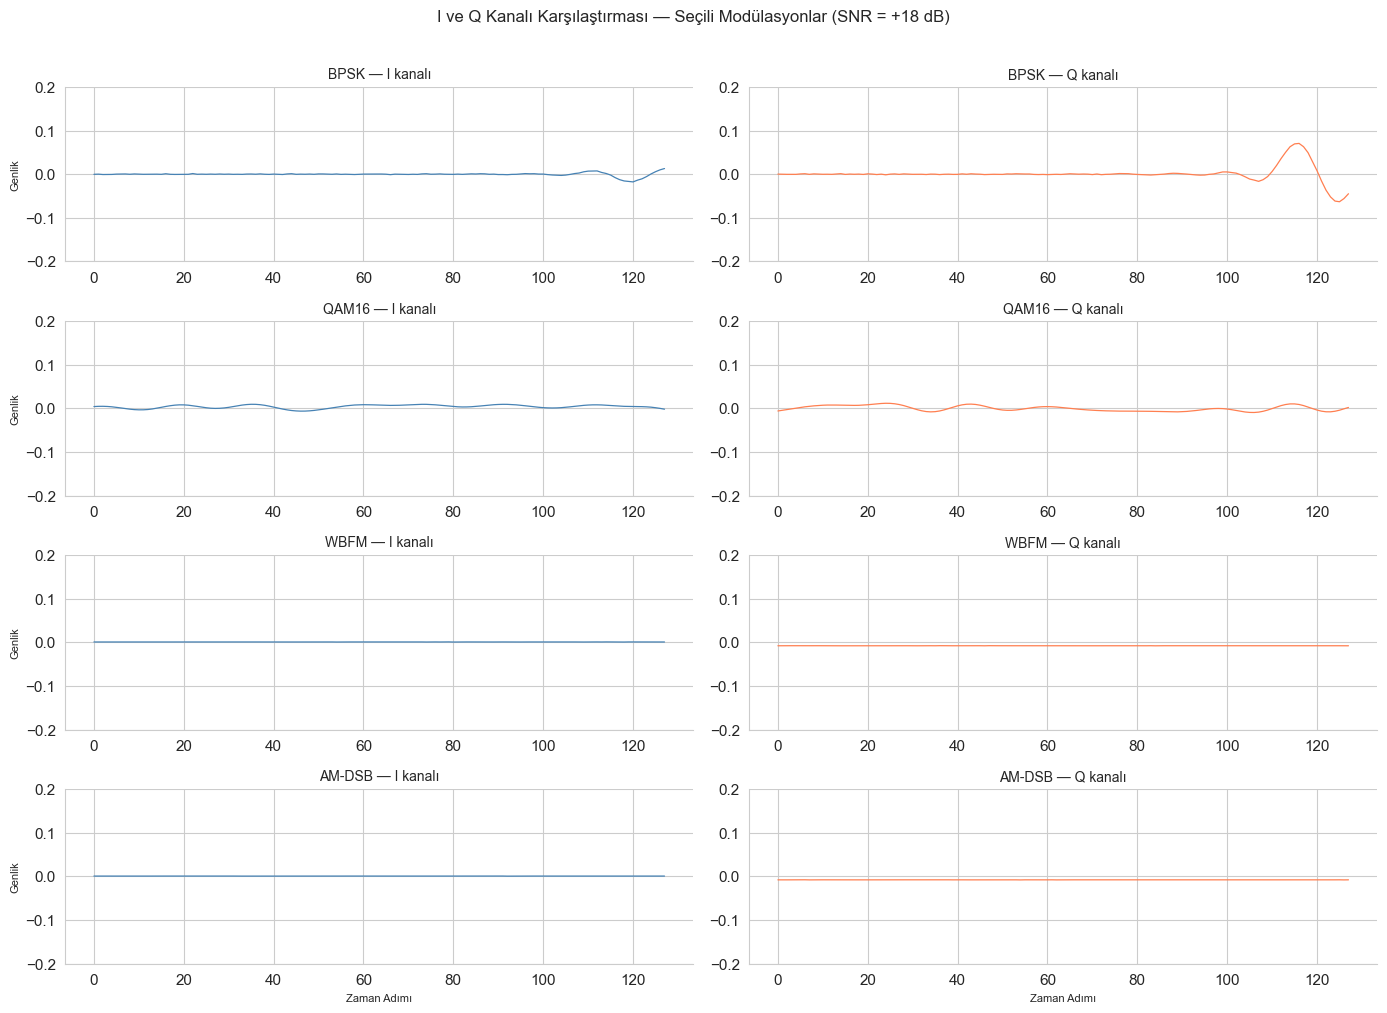

In [36]:
# Dijital vs analog ayrımını görmek için 4 temsili sınıf seç
selected_mods = ['BPSK', 'QAM16', 'WBFM', 'AM-DSB']
snr_to_show   = 18

fig, axes = plt.subplots(4, 2, figsize=(14, 10))

for row, mod in enumerate(selected_mods):
    signal    = dataset[(mod, snr_to_show)][0]
    i_channel = signal[0]
    q_channel = signal[1]

    # I kanalı
    axes[row, 0].plot(i_channel, color='steelblue', linewidth=0.9)
    axes[row, 0].set_title(f'{mod} — I kanalı', fontsize=10)
    axes[row, 0].set_ylabel('Genlik', fontsize=8)
    axes[row, 0].set_ylim(-0.2, 0.2)
    sns.despine(ax=axes[row, 0])

    # Q kanalı
    axes[row, 1].plot(q_channel, color='coral', linewidth=0.9)
    axes[row, 1].set_title(f'{mod} — Q kanalı', fontsize=10)
    axes[row, 1].set_ylim(-0.2, 0.2)
    sns.despine(ax=axes[row, 1])

for ax in axes[-1]:
    ax.set_xlabel('Zaman Adımı', fontsize=8)

fig.suptitle('I ve Q Kanalı Karşılaştırması — Seçili Modülasyonlar (SNR = +18 dB)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('../results/results_2016/eda_2016_waveforms_IQ_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

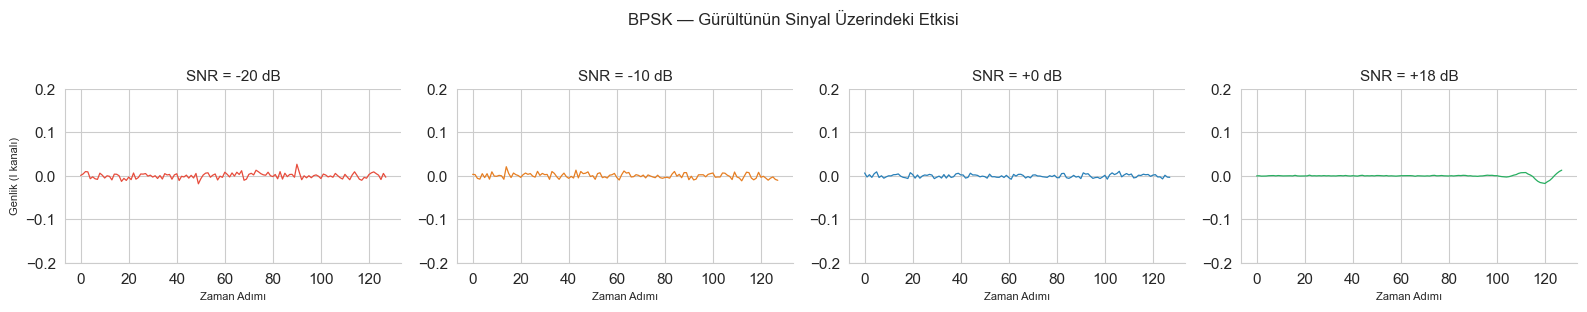

In [37]:
# BPSK sinyalinin gürültüyle nasıl bozulduğunu göster
mod_to_show = 'BPSK'
snr_levels_to_show = [-20, -10, 0, 18]
colors = ['#e74c3c', '#e67e22', '#2980b9', '#27ae60']

fig, axes = plt.subplots(1, 4, figsize=(16, 3))

for idx, (snr_val, color) in enumerate(zip(snr_levels_to_show, colors)):
    signal    = dataset[(mod_to_show, snr_val)][0]
    i_channel = signal[0]

    axes[idx].plot(i_channel, color=color, linewidth=0.9)
    axes[idx].set_title(f'SNR = {snr_val:+d} dB', fontsize=11)
    axes[idx].set_xlabel('Zaman Adımı', fontsize=8)
    axes[idx].set_ylim(-0.2, 0.2)
    if idx == 0:
        axes[idx].set_ylabel('Genlik (I kanalı)', fontsize=8)
    sns.despine(ax=axes[idx])

fig.suptitle(f'{mod_to_show} — Gürültünün Sinyal Üzerindeki Etkisi',
             fontsize=12, y=1.03)
plt.tight_layout()
plt.savefig('../results/results_2016/eda_2016_snr_effect_BPSK.png', dpi=150, bbox_inches='tight')
plt.show()

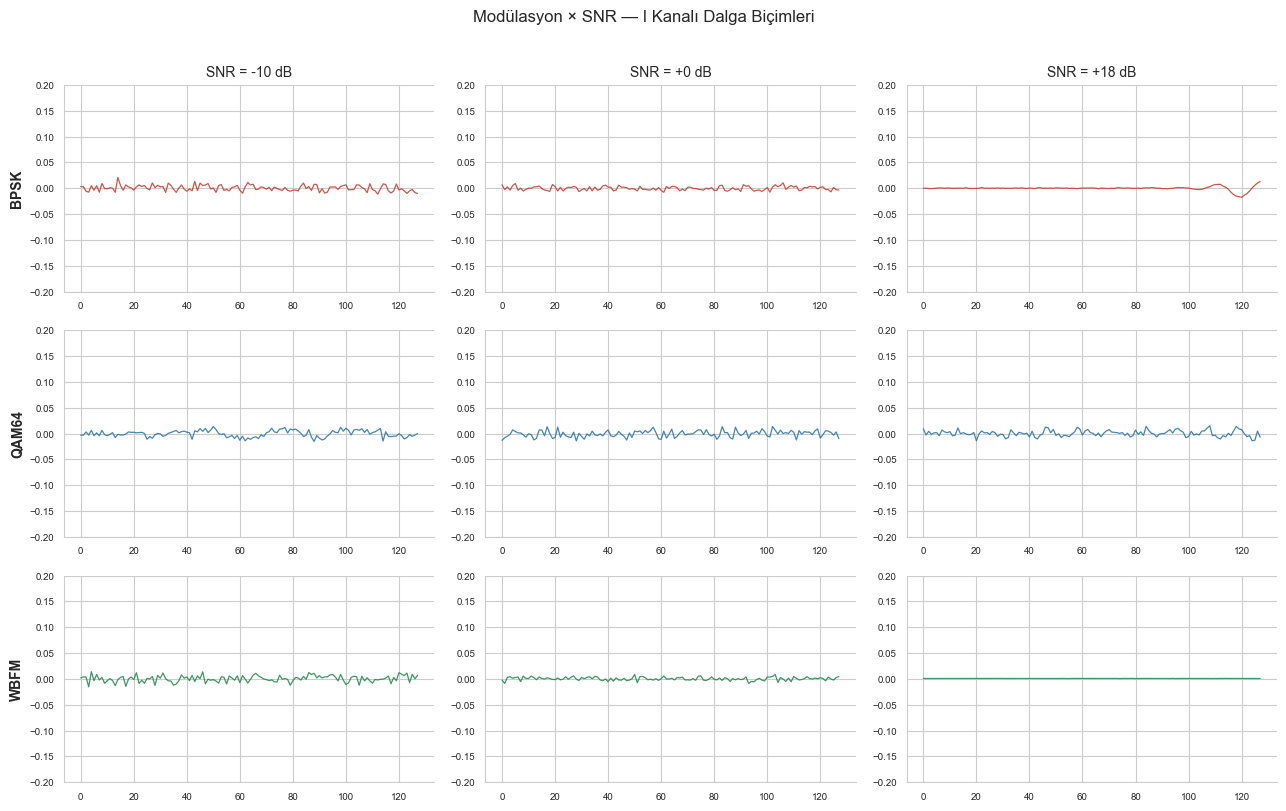

In [38]:
mods_to_compare = ['BPSK', 'QAM64', 'WBFM']
snrs_to_compare = [-10, 0, 18]
row_colors      = ['#c0392b', '#2471a3', '#1e8449']

fig, axes = plt.subplots(3, 3, figsize=(13, 8))

for row, (mod, color) in enumerate(zip(mods_to_compare, row_colors)):
    for col, snr_val in enumerate(snrs_to_compare):
        signal = dataset[(mod, snr_val)][0][0]   # I kanalı
        axes[row, col].plot(signal, color=color, linewidth=0.9, alpha=0.85)
        axes[row, col].set_ylim(-0.2, 0.2)
        axes[row, col].tick_params(labelsize=7)
        sns.despine(ax=axes[row, col])

        if row == 0:
            axes[row, col].set_title(f'SNR = {snr_val:+d} dB', fontsize=10)
        if col == 0:
            axes[row, col].set_ylabel(mod, fontsize=10, fontweight='bold')

fig.suptitle('Modülasyon × SNR — I Kanalı Dalga Biçimleri', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('../results/results_2016/eda_2016_waveform_grid.png', dpi=150, bbox_inches='tight')
plt.show()

Adım 3 — SNR etkisi

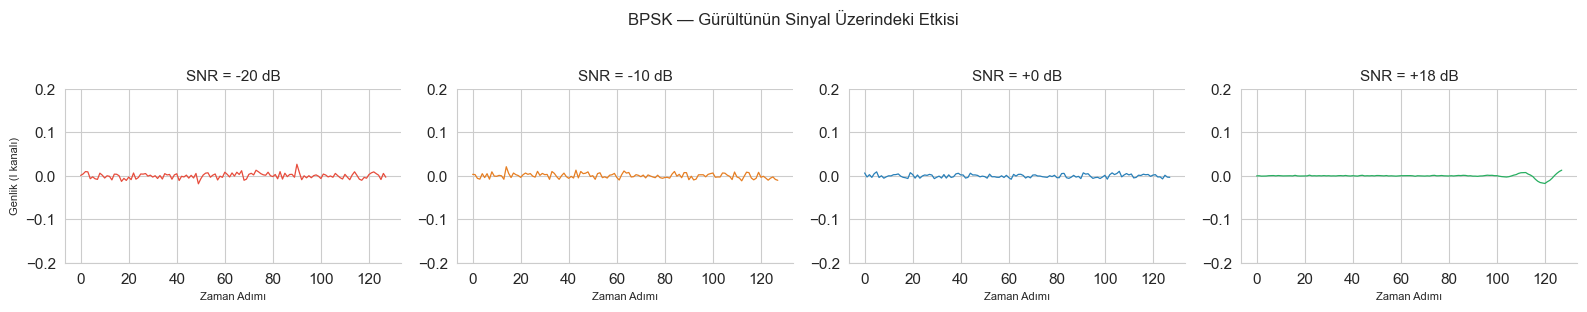

In [39]:
mod_to_show        = 'BPSK'
snr_levels_to_show = [-20, -10, 0, 18]
colors             = ['#e74c3c', '#e67e22', '#2980b9', '#27ae60']

fig, axes = plt.subplots(1, 4, figsize=(16, 3))

for idx, (snr_val, color) in enumerate(zip(snr_levels_to_show, colors)):
    signal    = dataset[(mod_to_show, snr_val)][0]
    i_channel = signal[0]

    axes[idx].plot(i_channel, color=color, linewidth=0.9)
    axes[idx].set_title(f'SNR = {snr_val:+d} dB', fontsize=11)
    axes[idx].set_xlabel('Zaman Adımı', fontsize=8)
    axes[idx].set_ylim(-0.2, 0.2)
    if idx == 0:
        axes[idx].set_ylabel('Genlik (I kanalı)', fontsize=8)
    sns.despine(ax=axes[idx])

fig.suptitle(f'{mod_to_show} — Gürültünün Sinyal Üzerindeki Etkisi',
             fontsize=12, y=1.03)
plt.tight_layout()
plt.savefig('../results/results_2016/eda_2016_snr_effect_BPSK.png', dpi=150, bbox_inches='tight')
plt.show()

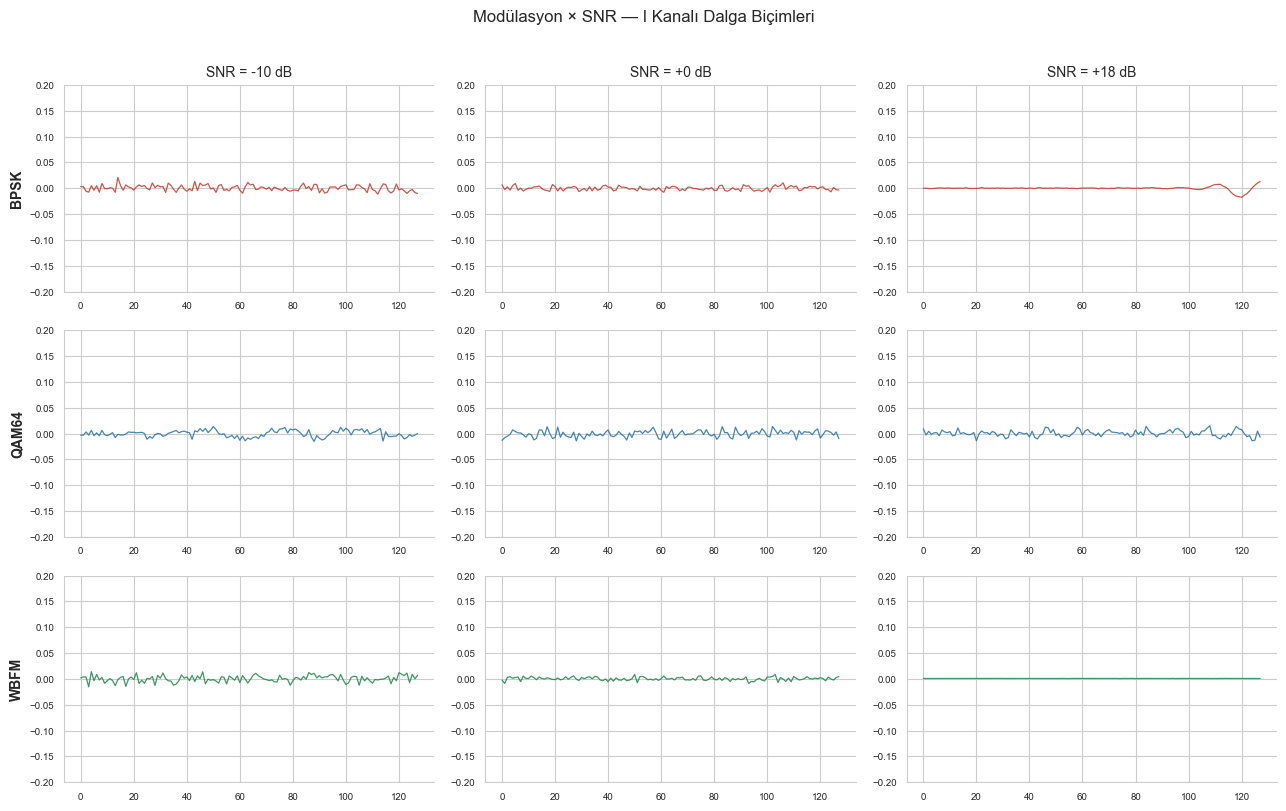

In [40]:
mods_to_compare = ['BPSK', 'QAM64', 'WBFM']
snrs_to_compare = [-10, 0, 18]
row_colors      = ['#c0392b', '#2471a3', '#1e8449']

fig, axes = plt.subplots(3, 3, figsize=(13, 8))

for row, (mod, color) in enumerate(zip(mods_to_compare, row_colors)):
    for col, snr_val in enumerate(snrs_to_compare):
        signal = dataset[(mod, snr_val)][0][0]  # I kanalı
        axes[row, col].plot(signal, color=color, linewidth=0.9, alpha=0.85)
        axes[row, col].set_ylim(-0.2, 0.2)
        axes[row, col].tick_params(labelsize=7)
        sns.despine(ax=axes[row, col])

        if row == 0:
            axes[row, col].set_title(f'SNR = {snr_val:+d} dB', fontsize=10)
        if col == 0:
            axes[row, col].set_ylabel(mod, fontsize=10, fontweight='bold')

fig.suptitle('Modülasyon × SNR — I Kanalı Dalga Biçimleri', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('../results/results_2016/eda_2016_snr_effect_grid.png', dpi=150, bbox_inches='tight')
plt.show()

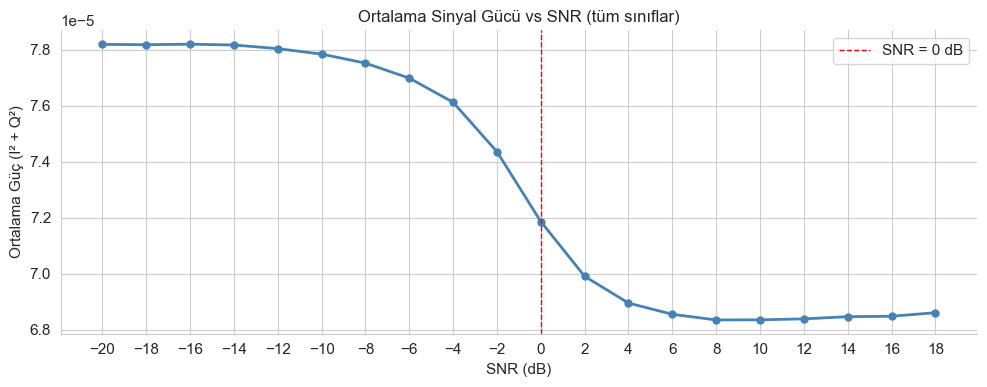


SNR bazlı ortalama güç değerleri:
snr
-20    0.000078
-18    0.000078
-16    0.000078
-14    0.000078
-12    0.000078
-10    0.000078
-8     0.000078
-6     0.000077
-4     0.000076
-2     0.000074
 0     0.000072
 2     0.000070
 4     0.000069
 6     0.000069
 8     0.000068
 10    0.000068
 12    0.000068
 14    0.000068
 16    0.000068
 18    0.000069


In [41]:
# Her (mod, snr) için ortalama sinyal gücünü hesapla
# Güç = mean(I² + Q²)
power_records = []

for (mod, snr_val), signals in dataset.items():
    power = np.mean(signals[:, 0, :]**2 + signals[:, 1, :]**2)
    power_records.append({'mod': mod, 'snr': snr_val, 'power': power})

power_df = pd.DataFrame(power_records)

# Her SNR için tüm sınıfların ortalama gücü
mean_power_by_snr = power_df.groupby('snr')['power'].mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(mean_power_by_snr.index, mean_power_by_snr.values,
        marker='o', color='steelblue', linewidth=2, markersize=5)
ax.axvline(x=0, color='red', linestyle='--', linewidth=1, label='SNR = 0 dB')
ax.set_title('Ortalama Sinyal Gücü vs SNR (tüm sınıflar)', fontsize=12)
ax.set_xlabel('SNR (dB)')
ax.set_ylabel('Ortalama Güç (I² + Q²)')
ax.set_xticks(snr_values)
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig('../results/results_2016/eda_2016_power_vs_snr.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSNR bazlı ortalama güç değerleri:")
print(mean_power_by_snr.round(6).to_string())

Adım 4 — Konstelasyon diyagramı

In [42]:
def normalize_signals(signals):
    """
    Her sinyali kendi gücüne göre normalize eder.
    Girdi: (N, 2, 128)
    Çıktı: I ve Q değerlerinin düz listesi
    """
    all_i, all_q = [], []
    for sig in signals:
        i, q  = sig[0], sig[1]
        power = np.sqrt(np.mean(i**2 + q**2))
        if power > 0:
            all_i.append(i / power)
            all_q.append(q / power)
    return np.concatenate(all_i), np.concatenate(all_q)

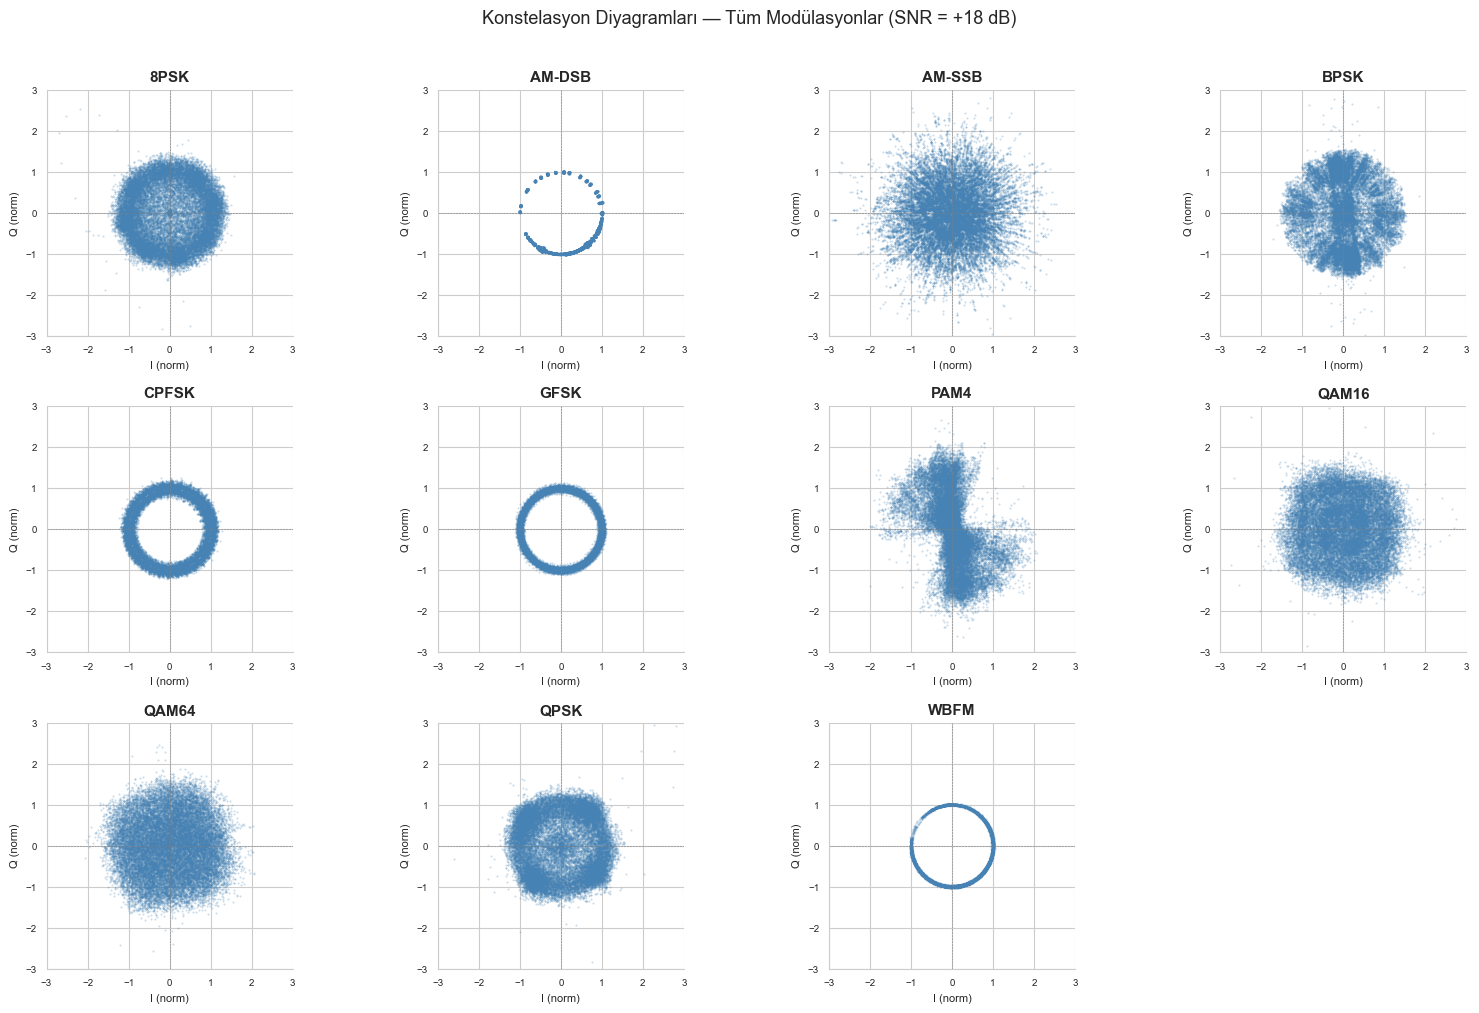

In [43]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes      = axes.flatten()
snr_show  = 18
n_samples = 200

for idx, mod in enumerate(modulations):
    signals       = dataset[(mod, snr_show)][:n_samples]
    i_vals, q_vals = normalize_signals(signals)

    axes[idx].scatter(i_vals, q_vals, s=0.2, alpha=0.3, color='steelblue')
    axes[idx].set_title(f'{mod}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('I (norm)', fontsize=8)
    axes[idx].set_ylabel('Q (norm)', fontsize=8)
    axes[idx].set_xlim(-3, 3)
    axes[idx].set_ylim(-3, 3)
    axes[idx].axhline(0, color='gray', linewidth=0.4, linestyle='--')
    axes[idx].axvline(0, color='gray', linewidth=0.4, linestyle='--')
    axes[idx].set_aspect('equal')
    axes[idx].tick_params(labelsize=7)
    sns.despine(ax=axes[idx])

axes[-1].set_visible(False)
fig.suptitle(f'Konstelasyon Diyagramları — Tüm Modülasyonlar (SNR = +{snr_show} dB)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../results/results_2016/eda_2016_constellation_all.png', dpi=150, bbox_inches='tight')
plt.show()

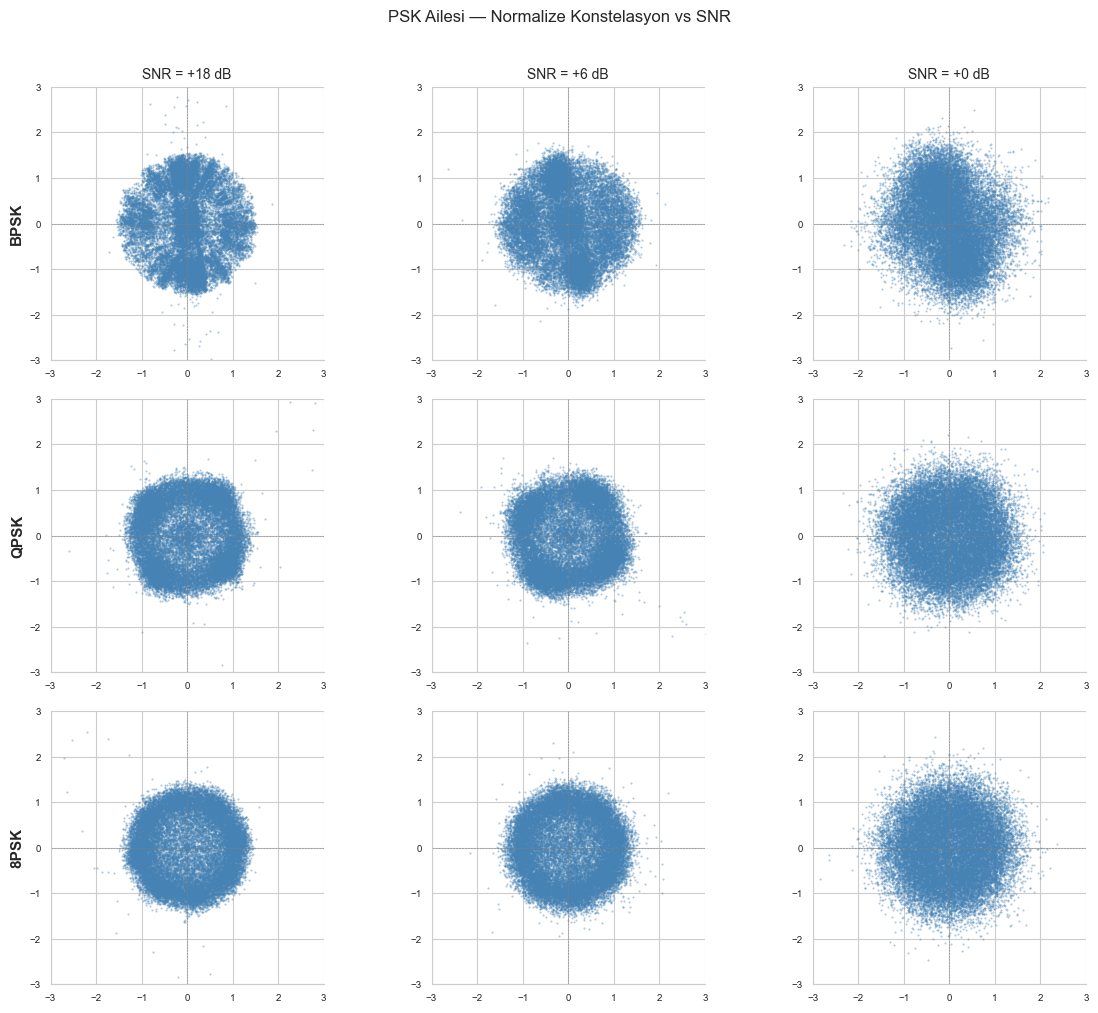

In [44]:
psk_mods = ['BPSK', 'QPSK', '8PSK']
snr_vals = [18, 6, 0]

fig, axes = plt.subplots(3, 3, figsize=(12, 10))

for row, mod in enumerate(psk_mods):
    for col, snr_val in enumerate(snr_vals):
        signals        = dataset[(mod, snr_val)][:200]
        i_vals, q_vals = normalize_signals(signals)

        axes[row, col].scatter(i_vals, q_vals, s=0.3, alpha=0.4, color='steelblue')
        axes[row, col].set_xlim(-3, 3)
        axes[row, col].set_ylim(-3, 3)
        axes[row, col].axhline(0, color='gray', linewidth=0.4, linestyle='--')
        axes[row, col].axvline(0, color='gray', linewidth=0.4, linestyle='--')
        axes[row, col].set_aspect('equal')
        axes[row, col].tick_params(labelsize=7)
        sns.despine(ax=axes[row, col])
        if row == 0:
            axes[row, col].set_title(f'SNR = {snr_val:+d} dB', fontsize=10)
        if col == 0:
            axes[row, col].set_ylabel(mod, fontsize=11, fontweight='bold')

fig.suptitle('PSK Ailesi — Normalize Konstelasyon vs SNR', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('../results/results_2016/eda_2016_constellation_PSK.png', dpi=150, bbox_inches='tight')
plt.show()

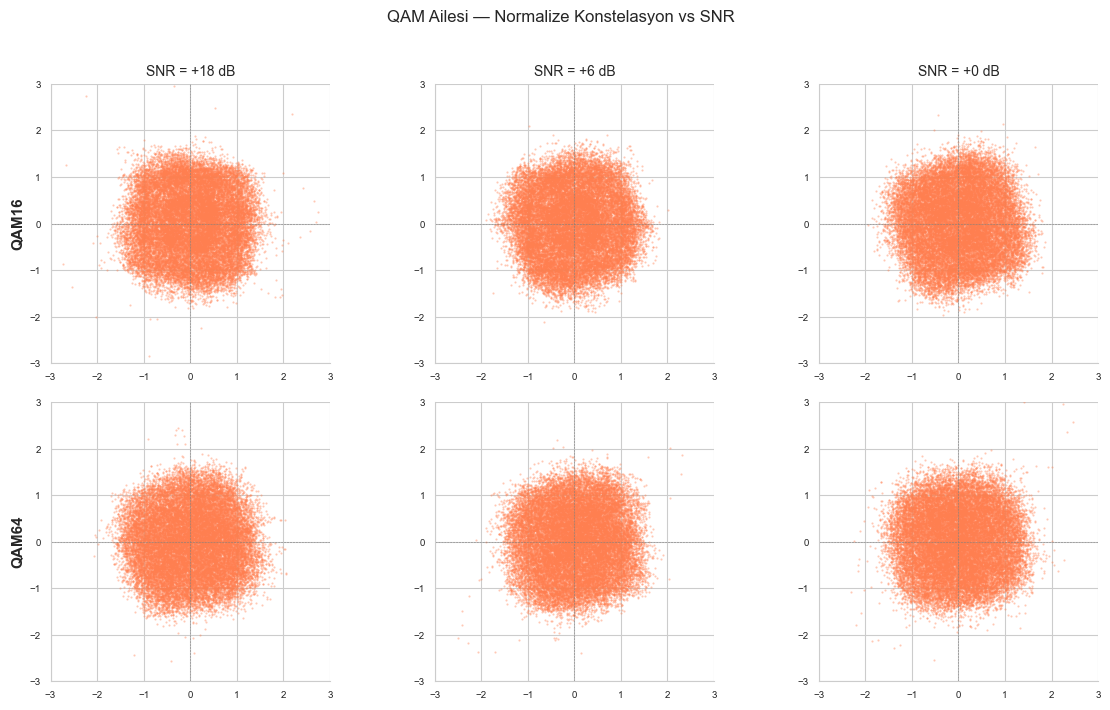

In [45]:
qam_mods = ['QAM16', 'QAM64']
snr_vals = [18, 6, 0]

fig, axes = plt.subplots(2, 3, figsize=(12, 7))

for row, mod in enumerate(qam_mods):
    for col, snr_val in enumerate(snr_vals):
        signals        = dataset[(mod, snr_val)][:200]
        i_vals, q_vals = normalize_signals(signals)

        axes[row, col].scatter(i_vals, q_vals, s=0.3, alpha=0.4, color='coral')
        axes[row, col].set_xlim(-3, 3)
        axes[row, col].set_ylim(-3, 3)
        axes[row, col].axhline(0, color='gray', linewidth=0.4, linestyle='--')
        axes[row, col].axvline(0, color='gray', linewidth=0.4, linestyle='--')
        axes[row, col].set_aspect('equal')
        axes[row, col].tick_params(labelsize=7)
        sns.despine(ax=axes[row, col])
        if row == 0:
            axes[row, col].set_title(f'SNR = {snr_val:+d} dB', fontsize=10)
        if col == 0:
            axes[row, col].set_ylabel(mod, fontsize=11, fontweight='bold')

fig.suptitle('QAM Ailesi — Normalize Konstelasyon vs SNR', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('../results/results_2016/eda_2016_constellation_QAM.png', dpi=150, bbox_inches='tight')
plt.show()

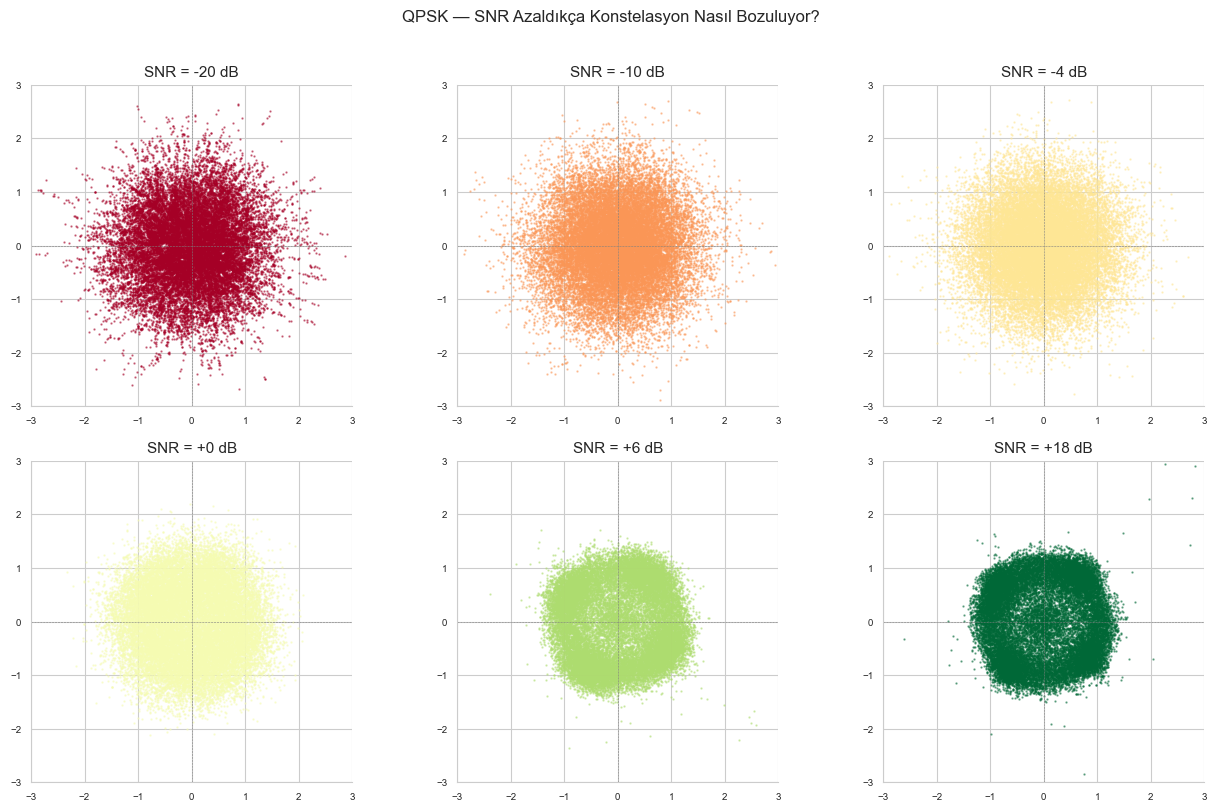

In [46]:
mod_to_show = 'QPSK'
snr_steps   = [-20, -10, -4, 0, 6, 18]

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes      = axes.flatten()

for idx, snr_val in enumerate(snr_steps):
    signals        = dataset[(mod_to_show, snr_val)][:200]
    i_vals, q_vals = normalize_signals(signals)
    color          = plt.cm.RdYlGn((snr_val + 20) / 38)

    axes[idx].scatter(i_vals, q_vals, s=0.5, alpha=0.5, color=color)
    axes[idx].set_title(f'SNR = {snr_val:+d} dB', fontsize=11)
    axes[idx].set_xlim(-3, 3)
    axes[idx].set_ylim(-3, 3)
    axes[idx].axhline(0, color='gray', linewidth=0.4, linestyle='--')
    axes[idx].axvline(0, color='gray', linewidth=0.4, linestyle='--')
    axes[idx].set_aspect('equal')
    axes[idx].tick_params(labelsize=7)
    sns.despine(ax=axes[idx])

fig.suptitle(f'{mod_to_show} — SNR Azaldıkça Konstelasyon Nasıl Bozuluyor?',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('../results/results_2016/eda_2016_constellation_QPSK_snr.png', dpi=150, bbox_inches='tight')
plt.show()

ADIM 5 — İstatistiksel özet ve eksik veri

RadioML 2016.10a sentetik ve tam etiketlidir; ADIM-0’da NaN/Inf ve şekil kontrolleri yapıldı. **Eksik veri işleme:** gerçek üretimde `np.nan_to_num` veya satır düşürme kullanılır; bu veri setinde genelde işlem gerekmez. Aşağıda sınıf bazlı I/Q özetleri ve güvenlik için küçük bir sanitizasyon örneği var.

In [47]:
import os
import numpy as np

os.makedirs("../results/results_2016", exist_ok=True)

print("Eksik veri / sayısal güvenlik (sanitize)")
print("-" * 40)


def sanitize_iq(x):
    """NaN/Inf varsa 0'a çeker; RadioML'de genelde tetiklenmez."""
    return np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)


probe = sanitize_iq(X[:2048])
print(f"Sanitize sonrası (ilk 2048 örnek) NaN: {np.isnan(probe).any()}, Inf: {np.isinf(probe).any()}")

Eksik veri / sayısal güvenlik (sanitize)
----------------------------------------
Sanitize sonrası (ilk 2048 örnek) NaN: False, Inf: False


In [48]:
import pandas as pd

print("=" * 52)
print("  Sınıf bazlı I/Q istatistiksel özeti")
print("=" * 52)

rows = []
for mod in modulations:
    m = y == mod
    i_flat = X[m, 0].ravel()
    q_flat = X[m, 1].ravel()
    rows.append({
        "modulation": mod,
        "n": int(m.sum()),
        "I_mean": float(i_flat.mean()),
        "I_std": float(i_flat.std()),
        "I_min": float(i_flat.min()),
        "I_max": float(i_flat.max()),
        "Q_mean": float(q_flat.mean()),
        "Q_std": float(q_flat.std()),
        "Q_min": float(q_flat.min()),
        "Q_max": float(q_flat.max()),
    })

stats_by_class = pd.DataFrame(rows).set_index("modulation").sort_index()
print(stats_by_class.round(6).to_string())
print()

out_stats = "../results/results_2016/eda_2016_stats_by_class.csv"
stats_by_class.to_csv(out_stats)
print(f"CSV kaydedildi: {out_stats}")

  Sınıf bazlı I/Q istatistiksel özeti
                n    I_mean     I_std     I_min     I_max    Q_mean     Q_std     Q_min     Q_max
modulation                                                                                       
8PSK        20000 -0.000091  0.006003 -0.073416  0.097091 -0.000027  0.006033 -0.154946  0.055247
AM-DSB      20000  0.001086  0.005195 -0.027984  0.030807 -0.003390  0.005489 -0.028658  0.027423
AM-SSB      20000 -0.000161  0.006221 -0.029821  0.030667 -0.000041  0.006282 -0.028998  0.027936
BPSK        20000 -0.000091  0.005722 -0.029725  0.031225 -0.000013  0.006445 -0.066338  0.164229
CPFSK       20000 -0.000090  0.005907 -0.028951  0.030704 -0.000037  0.005935 -0.028232  0.026612
GFSK        20000 -0.000075  0.005898 -0.027790  0.030554 -0.000030  0.005934 -0.030739  0.026997
PAM4        20000 -0.000087  0.005307 -0.033992  0.030459 -0.000006  0.007193 -0.151189  0.114144
QAM16       20000 -0.000062  0.006066 -0.075481  0.160467 -0.000033  0.006088 -0

In [49]:
import numpy as np
import pandas as pd

print("=" * 52)
print("  Global I/Q özeti (tüm örnekler düzleştirilmiş)")
print("=" * 52)
g_i = X[:, 0].ravel()
g_q = X[:, 1].ravel()
global_summary = pd.DataFrame([{
    "I_mean": g_i.mean(),
    "I_std": g_i.std(),
    "Q_mean": g_q.mean(),
    "Q_std": g_q.std(),
    "I_Q_pearson_flat_sample": np.corrcoef(g_i[::500], g_q[::500])[0, 1],
}])
print("I_Q_pearson_flat_sample: her 500. örneklem (maliyet için)")
print(global_summary.round(6).to_string(index=False))

  Global I/Q özeti (tüm örnekler düzleştirilmiş)
I_Q_pearson_flat_sample: her 500. örneklem (maliyet için)
 I_mean    I_std    Q_mean    Q_std  I_Q_pearson_flat_sample
0.00007 0.005811 -0.000617 0.006246                -0.034688


ADIM 6 — Öznitelik mühendisliği, korelasyon ve PCA

Ham I/Q (2×128) CNN’e doğrudan verilir; burada **EDA ve olası RF baseline** için düşük boyutlu öznitelikler türetiliyor. Korelasyon matrisi bu öznitelikler üzerinde (tam 256 örneklem üzerinde değil — maliyet). PCA, `sklearn` ile standartlaştırılmış özniteliklerde hesaplanır (önceki hücrelerdeki gibi her grafik ayrı kod hücresinde).

In [50]:
import os
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

os.makedirs("../results/results_2016", exist_ok=True)


In [51]:
FEATURE_NAMES = [
    "I_mu", "I_std", "Q_mu", "Q_std",
    "env_mu", "env_std", "zcr_I",
    "spec_low",
]


def handcrafted_features(sig):
    """sig: (2, 128)"""
    i, q = sig[0].astype(np.float64), sig[1].astype(np.float64)
    env = np.sqrt(i * i + q * q)
    centered = i - i.mean()
    zcr = np.sum(np.diff(np.sign(centered)) != 0) / max(len(i) - 1, 1)
    spec = np.abs(np.fft.rfft(i))
    spec_low = float(spec[: min(32, spec.size)].mean())
    return np.array(
        [i.mean(), i.std(), q.mean(), q.std(), env.mean(), env.std(), zcr, spec_low],
        dtype=np.float64,
    )


rng = np.random.default_rng(42)
N_FEAT = min(12_000, len(X))
idx = rng.choice(len(X), size=N_FEAT, replace=False)
X_sub = X[idx]
y_sub = y[idx]
snr_sub = snr[idx]

F = np.stack([handcrafted_features(X_sub[i]) for i in range(N_FEAT)])
feat_df = pd.DataFrame(F, columns=FEATURE_NAMES)
feat_df["modulation"] = y_sub
feat_df["snr_db"] = snr_sub

print(f"Öznitelik matrisi: {F.shape} (satır={N_FEAT})")


Öznitelik matrisi: (12000, 8) (satır=12000)


In [52]:
print("=" * 52)
print("  El yapımı öznitelikler — describe() özeti")
print("=" * 52)
print()
print(feat_df[FEATURE_NAMES].describe().T.round(6).to_string())


  El yapımı öznitelikler — describe() özeti

            count      mean       std       min       25%       50%       75%       max
I_mu      12000.0  0.000041  0.001766 -0.007810 -0.000700 -0.000058  0.000669  0.007812
I_std     12000.0  0.005249  0.001749  0.000040  0.005126  0.005870  0.006245  0.017505
Q_mu      12000.0 -0.000615  0.002341 -0.007812 -0.001099 -0.000180  0.000528  0.007812
Q_std     12000.0  0.005539  0.001755  0.000037  0.005339  0.005994  0.006370  0.022262
env_mu    12000.0  0.007813  0.000000  0.007812  0.007812  0.007813  0.007813  0.007813
env_std   12000.0  0.003228  0.001375  0.000039  0.002593  0.003766  0.004145  0.022734
zcr_I     12000.0  0.315867  0.195543  0.007874  0.086614  0.409449  0.488189  0.645669
spec_low  12000.0  0.054897  0.016335  0.000748  0.049541  0.059232  0.065289  0.203955


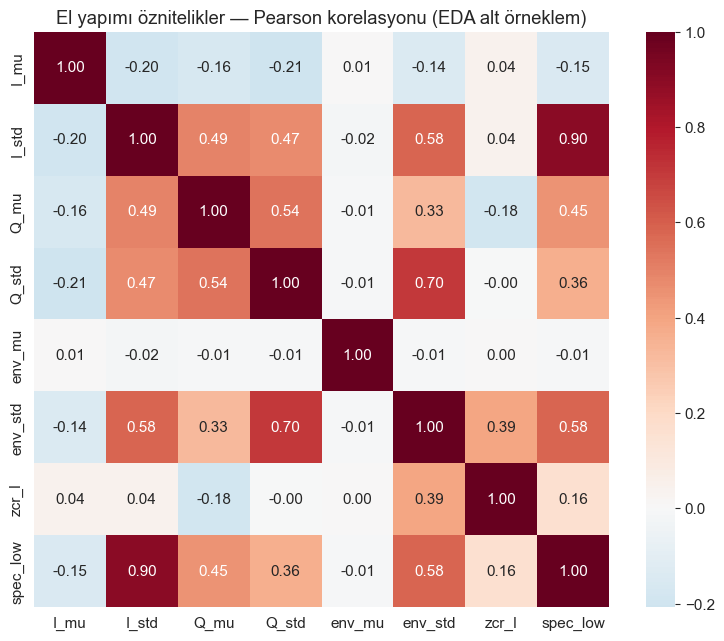

CSV kaydedildi: ../results/eda_2016_feature_correlation_matrix.csv


In [53]:
corr = feat_df[FEATURE_NAMES].corr()
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax, square=True)
ax.set_title("El yapımı öznitelikler — Pearson korelasyonu (EDA alt örneklem)")
plt.tight_layout()
plt.savefig("../results/results_2016/eda_2016_feature_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

corr_path = "../results/results_2016/eda_2016_feature_correlation_matrix.csv"
corr.to_csv(corr_path)
print(f"CSV kaydedildi: {corr_path}")


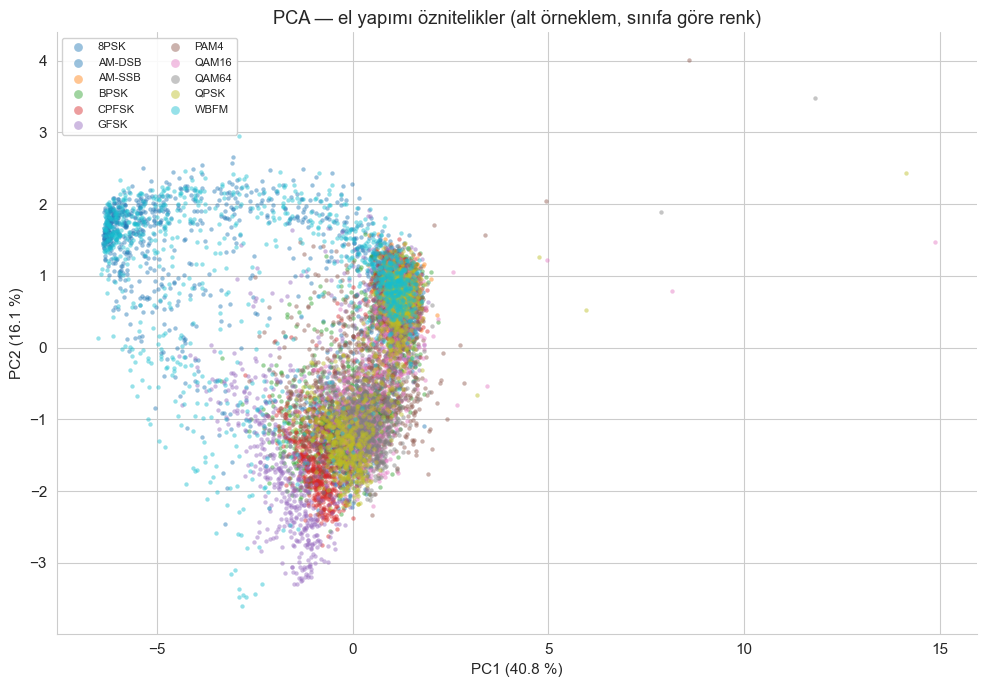


PCA açıklanan varyans oranı: [0.4078 0.1611]


In [54]:
scaler = StandardScaler()
Fz = scaler.fit_transform(F)
pca = PCA(n_components=2, random_state=42)
Z = pca.fit_transform(Fz)

le = LabelEncoder()
labels = le.fit_transform(y_sub)
colors = plt.cm.tab10(np.linspace(0, 1, len(le.classes_), endpoint=False))

fig, ax = plt.subplots(figsize=(10, 7))
for k, mod_name in enumerate(le.classes_):
    m = labels == k
    ax.scatter(Z[m, 0], Z[m, 1], s=10, alpha=0.45, c=[colors[k]], label=mod_name, linewidths=0)
ax.legend(markerscale=2, fontsize=8, loc="best", ncol=2, framealpha=0.9)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f} %)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f} %)")
ax.set_title("PCA — el yapımı öznitelikler (alt örneklem, sınıfa göre renk)")
sns.despine()
plt.tight_layout()
plt.savefig("../results/results_2016/eda_2016_pca_handcrafted.png", dpi=150, bbox_inches="tight")
plt.show()

print()
print("PCA açıklanan varyans oranı:", pca.explained_variance_ratio_.round(4))


## 7 — EDA özet bulguları (rapora aktarılacak çerçeve)

Bu bölüm, RadioML 2016.10a üzerindeki keşifsel analizin tek cümlelik özeti değil; **Faz 3 raporuna** veya IEEE tarzı teknik rapora doğrudan taşınabilecek bulgu başlıklarını içerir. Sayısal değerler notebook çıktıları ve `../results/results_2016/` altındaki CSV dosyalarıyla çapraz doğrulanmalıdır.

### 7.1 Veri yapısı ve tutarlılık
- Toplam **220.000** örnek: **11 modülasyon × 20 SNR seviyesi × 1000 örnek**; sözlük anahtar sayısı **220**, beklenen çarpımla uyumlu.
- Her örnek **(2, 128)** boyutunda: kanal 0 = **I (in-phase)**, kanal 1 = **Q (quadrature)**; Faz 1 problem tanımıyla örtüşür.
- SNR aralığı **−20 dB … +18 dB**, **2 dB** adım; literatürdeki RadioML 2016.10a tanımıyla uyumludur.

### 7.2 Veri kalitesi ve eksik değer
- Tüm anahtarlar için **NaN / Inf** ve **şekil (1000, 2, 128)** kontrolleri geçti; sentetik veri setinde beklenen **tam ve düzenli** yapı doğrulandı.
- Genlik aralığı (min–max) özet istatistiklerle kayıt altına alındı; ileride gerçek kanal verisine geçişte **`sanitize_iq`** (NaN/Inf → 0) gibi bir ön adımın pipeline’da nerede duracağı netleştirildi.

### 7.3 Sınıf ve SNR dengesi
- **Sınıf başına 20.000** örnek; **SNR başına 11.000** örnek; **(sınıf × SNR)** hücresi başına **1000** örnek — denetimli öğrenme için **dengeli** bir düzen.
- Isı haritası, hiçbir hücrede eksik veya beklenmedik yoğunluk olmadığını gösterir; stratified bölümleme (Faz 2 planı) için uygundur.

### 7.4 Zaman domeni, SNR ve güç
- Yüksek SNR’de **I kanalı dalga formları** modülasyon ailelerine göre görsel olarak ayrışır; düşük SNR’de gürültü baskın hale gelir (BPSK örneği ve ızgaralar bunu somutlar).
- **Ortalama sinyal gücü (I²+Q²)** ile SNR ilişkisi çizildi; SNR’nin yalnızca etiket değil, sinyal istatistiği üzerinde de izlenebilir bir etkisi olduğu görülür.

### 7.5 Konstelasyon (I/Q uzayı)
- Normalize edilmiş **I–Q saçılımı**, PSK/QAM aileleri için yüksek SNR’de beklenen kümelenmeyi; SNR düştükçe **bulanıklaşmayı** gösterir.
- Bu görseller, derin modelin ham I/Q’da hangi yapıyı öğrenmesi gerektiğine dair **sezgisel referans** sağlar (CNN / hibrit mimari motivasyonu).

### 7.6 İstatistiksel özet ve el yapımı öznitelikler
- **Sınıf bazlı** I/Q için ortalama, standart sapma, min–max tablosu üretildi ve `eda_2016_stats_by_class.csv` olarak kaydedildi; raporda “Tablo: modülasyon başına I/Q özeti” diye referans verilebilir.
- **Global** düzleştirilmiş I/Q özeti ve (maliyet nedeniyle seyrek örneklemle) **I–Q Pearson** satırı, verinin genel ölçeklenmesi hakkında tek sayfalık özet sunar.
- Sekiz **el yapımı öznitelik** (kanal momentleri, zarf, sıfır geçiş, düşük bant spektral özet) yalnızca EDA ve olası **RF baseline** içindir; CNN girdisi yine **ham 2×128** olarak kalır.

### 7.7 Korelasyon ve PCA
- Öznitelikler arası **Pearson korelasyon ısı haritası** ve `eda_2016_feature_correlation_matrix.csv`, hangi türetilmiş büyüklüklerin birlikte hareket ettiğini gösterir (raporda kısa yorum: güçlü korelasyonlu çiftler, tek özellik gibi davranabilir).
- İki bileşenli **PCA** saçılımı, sınıfların el yapımı özellik uzayında **kısmen** ayrıldığını; tam ayrımın beklenmediğini (özellikle çok düşük SNR alt örneklemde) gösterir. Bu, Faz 1’deki “düşük SNR’de fiziksel sınır” literatür bulgusuyla tutarlıdır.

### 7.8 Faz 1 başarı ölçütleri ile bağlantı
- EDA, **genel doğruluk / SNR≥0 doğruluğu / makro F1** hedeflerini doğrudan ölçmez; ancak **dengeli veri** ve **SNR’ye duyarlı görünür ayrım** gözlemleri, bu metriklerin raporlanmasında SNR’ye göre doğruluk eğrisinin **yorumlanmasını** destekler.
- Karışıklık matrisi ve model kıyası bir sonraki fazda üretilecektir.

### 7.9 Bu notebook’tan çıkan dosyalar (rapora ek / referans listesi)
| Tür | Örnek dosya ( `../results/results_2016/` ) |
|-----|--------------------------------|
| Dağılım | `eda_2016_class_distribution.png`, `eda_2016_snr_distribution.png`, `eda_2016_class_snr_heatmap.png` |
| Dalga / SNR | `eda_2016_waveforms_*.png`, `eda_2016_power_vs_snr.png`, … |
| Konstelasyon | `eda_2016_constellation_*.png` |
| İstatistik | `eda_2016_stats_by_class.csv` |
| Öznitelik–EDA | `eda_2016_feature_correlation.png`, `eda_2016_feature_correlation_matrix.csv`, `eda_2016_pca_handcrafted.png` |

> Not: `results/` altındaki ikili çıktılar çoğu repoda `.gitignore` ile takip dışıdır; teslimde rapora veya `docs/figures/` altına kopyalanması önerilir.

### 7.10 Sonraki adımlar (EDA sonrası)
- Eğitim/val/test bölümlemesi (tercihen stratified; isteğe bağlı SNR bazlı test ayrımı — Faz 2 planı).
- Üç model hattı: **Random Forest** (mümkünse el yapımı veya düzleştirilmiş I/Q), **CNN**, **CNN+LSTM**; metrikler ve SNR eğrileri.
- Streamlit demosu için çevrimdışı örnek seçimi ve model yükleme.
